In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stores = pd.read_csv("stores.csv")
calendar = pd.read_csv("calendar.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")


In [155]:
print("Stores:", stores.shape)
print("Calendar:", calendar.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sales:", sales.shape)

Stores: (100, 5)
Calendar: (731, 6)
Customers: (50000, 5)
Products: (200, 6)
Sales: (1000000, 11)


In [156]:
print("Sales Columns:")
print(sales.columns)

print("\nCustomers Columns:")
print(customers.columns)

print("\nProducts Columns:")
print(products.columns)

print("\nStores Columns:")
print(stores.columns)

print("\nCalendar Columns:")
print(calendar.columns)

Sales Columns:
Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit'],
      dtype='object')

Customers Columns:
Index(['customer_id', 'age', 'gender', 'loyalty_member', 'join_date'], dtype='object')

Products Columns:
Index(['product_id', 'product_name', 'brand', 'category', 'cocoa_percent',
       'weight_g'],
      dtype='object')

Stores Columns:
Index(['store_id', 'store_name', 'city', 'country', 'store_type'], dtype='object')

Calendar Columns:
Index(['date', 'year', 'month', 'day', 'week', 'day_of_week'], dtype='object')


In [157]:
for name, df in [
    ("stores", stores),
    ("calendar", calendar),
    ("customers", customers),
    ("products", products),
    ("sales", sales),
]:
    missing = df.isna().sum()
    pct_missing = 100 * missing / len(df)
    print(f"{name.capitalize()} missing values:")
    print(pd.concat([missing, pct_missing], axis=1, keys=["missing", "% missing"]))
    print("\n")


Stores missing values:
            missing  % missing
store_id          0        0.0
store_name        0        0.0
city              0        0.0
country           0        0.0
store_type        0        0.0


Calendar missing values:
             missing  % missing
date               0        0.0
year               0        0.0
month              0        0.0
day                0        0.0
week               0        0.0
day_of_week        0        0.0


Customers missing values:
                missing  % missing
customer_id           0        0.0
age                   0        0.0
gender                0        0.0
loyalty_member        0        0.0
join_date             0        0.0


Products missing values:
               missing  % missing
product_id           0        0.0
product_name         0        0.0
brand                0        0.0
category             0        0.0
cocoa_percent        0        0.0
weight_g             0        0.0


Sales missing values:
             

In [158]:
for name, df in [
    ("stores", stores),
    ("calendar", calendar),
    ("customers", customers),
    ("products", products),
    ("sales", sales),
]:
    dup_count = df.duplicated().sum()
    print(f"{name.capitalize()} duplicate rows: {dup_count}")
    if dup_count > 0:
        print(df[df.duplicated(keep=False)].head())
    print("\n")

Stores duplicate rows: 0


Calendar duplicate rows: 0


Customers duplicate rows: 0


Products duplicate rows: 0


Sales duplicate rows: 0




In [159]:
for name, df in [
    ("stores", stores),
    ("calendar", calendar),
    ("customers", customers),
    ("products", products),
    ("sales", sales),
]:
    print(f"{name.capitalize()} dtypes:")
    print(df.dtypes)
    print("\n")

Stores dtypes:
store_id      object
store_name    object
city          object
country       object
store_type    object
dtype: object


Calendar dtypes:
date           object
year            int64
month           int64
day             int64
week            int64
day_of_week     int64
dtype: object


Customers dtypes:
customer_id       object
age                int64
gender            object
loyalty_member     int64
join_date         object
dtype: object


Products dtypes:
product_id       object
product_name     object
brand            object
category         object
cocoa_percent     int64
weight_g          int64
dtype: object


Sales dtypes:
order_id        object
order_date      object
product_id      object
store_id        object
customer_id     object
quantity         int64
unit_price     float64
discount       float64
revenue        float64
cost           float64
profit         float64
dtype: object




In [160]:
sales['order_date'] = pd.to_datetime(sales['order_date'])

customers['join_date'] = pd.to_datetime(customers['join_date'])

calendar['date'] = pd.to_datetime(calendar['date'])

In [161]:
print(sales.dtypes)

print(customers.dtypes)

print(calendar.dtypes)

order_id               object
order_date     datetime64[ns]
product_id             object
store_id               object
customer_id            object
quantity                int64
unit_price            float64
discount              float64
revenue               float64
cost                  float64
profit                float64
dtype: object
customer_id               object
age                        int64
gender                    object
loyalty_member             int64
join_date         datetime64[ns]
dtype: object
date           datetime64[ns]
year                    int64
month                   int64
day                     int64
week                    int64
day_of_week             int64
dtype: object


In [162]:
sales.info()
sales.isnull().sum()
sales.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   order_id     1000000 non-null  object        
 1   order_date   1000000 non-null  datetime64[ns]
 2   product_id   1000000 non-null  object        
 3   store_id     1000000 non-null  object        
 4   customer_id  1000000 non-null  object        
 5   quantity     1000000 non-null  int64         
 6   unit_price   1000000 non-null  float64       
 7   discount     1000000 non-null  float64       
 8   revenue      1000000 non-null  float64       
 9   cost         1000000 non-null  float64       
 10  profit       1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 83.9+ MB


np.int64(0)

In [163]:
merged = sales.merge(products, on="product_id", how="left")
merged = merged.merge(stores, on="store_id", how="left", suffixes=("", "_store"))
merged = merged.merge(customers, on="customer_id", how="left", suffixes=("", "_customer"))
merged = merged.merge(calendar, left_on="order_date", right_on="date", how="left", suffixes=("", "_calendar"))

print("Merged dataset shape:", merged.shape)
print("Missing values in merged dataset:")
print(merged.isna().sum().sort_values(ascending=False).head(20))
print("\nMerged columns:")
print(merged.columns)
merged.head()

Merged dataset shape: (1000000, 30)
Missing values in merged dataset:
weight_g          9764
cocoa_percent     9764
category          9764
brand             9764
product_name      9764
gender               0
store_type           0
age                  0
loyalty_member       0
city                 0
join_date            0
date                 0
year                 0
month                0
day                  0
week                 0
country              0
order_id             0
store_name           0
order_date           0
dtype: int64

Merged columns:
Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit',
       'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g',
       'store_name', 'city', 'country', 'store_type', 'age', 'gender',
       'loyalty_member', 'join_date', 'date', 'year', 'month', 'day', 'week',
       'day_of_week'],
      dtype='object')


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,age,gender,loyalty_member,join_date,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,44,Male,1,2021-11-17,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,63,Female,1,2023-07-03,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,35,Male,1,2023-10-09,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,37,Female,1,2023-05-30,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,57,Female,0,2021-08-20,2024-09-24,2024,9,24,39,1


In [164]:
merged

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,age,gender,loyalty_member,join_date,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,44,Male,1,2021-11-17,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,63,Female,1,2023-07-03,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,35,Male,1,2023-10-09,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,37,Female,1,2023-05-30,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,57,Female,0,2021-08-20,2024-09-24,2024,9,24,39,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0RD00999996,2023-04-15,P0103,S053,C044763,4,7.45,0.00,29.80,17.27,...,55,Male,1,2025-04-21,2023-04-15,2023,4,15,15,5
999996,0RD00999997,2023-05-26,P0094,S058,C004441,2,6.09,0.00,12.18,7.81,...,30,Female,1,2022-07-23,2023-05-26,2023,5,26,21,4
999997,0RD00999998,2023-07-05,P0097,S041,C044879,3,6.09,0.00,18.27,10.11,...,33,Male,0,2022-03-31,2023-07-05,2023,7,5,27,2
999998,0RD00999999,2024-01-03,P0090,S083,C042525,1,4.90,0.00,4.90,2.56,...,52,Male,0,2021-12-25,2024-01-03,2024,1,3,1,2


In [165]:
merged.columns

Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit',
       'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g',
       'store_name', 'city', 'country', 'store_type', 'age', 'gender',
       'loyalty_member', 'join_date', 'date', 'year', 'month', 'day', 'week',
       'day_of_week'],
      dtype='object')

In [166]:
total_revenue = merged["revenue"].sum()
print("Total revenue:", total_revenue)

Total revenue: 25486128.86


In [167]:
average_profit = merged["profit"].mean()
print("Average profit:", average_profit)


Average profit: 10.194564629999999


In [168]:
category_revenue = merged.groupby("category")["revenue"].sum().sort_values(ascending=False)
top_category = category_revenue.idxmax()
top_value = category_revenue.max()
print("Top product category by revenue:", top_category)
print("Revenue:", top_value)
category_revenue.head(5)

Top product category by revenue: Praline
Revenue: 6665641.32


category
Praline    6665641.32
White      6070172.20
Dark       5298123.27
Truffle    3924343.24
Milk       3280368.19
Name: revenue, dtype: float64

In [169]:
merged.describe()

,order_date,quantity,unit_price,discount,revenue,cost,profit,cocoa_percent,weight_g,age,loyalty_member,join_date,date,year,month,day,week,day_of_week
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,990236.000000,990236.000000,1000000.000000,1000000.000000,1000000,1000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2023-12-31 19:03:34.991998720,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565,69.148132,107.431400,44.044222,0.501898,2023-09-06 09:28:29.423999744,2023-12-31 19:03:34.991998720,2023.50043,6.516521,15.726768,26.444866,2.999049
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,50.000000,50.000000,18.000000,0.000000,2021-03-06 00:00:00,2023-01-01 00:00:00,2023.00000,1.000000,1.000000,1.000000,0.000000
25%,2023-07-02 00:00:00,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,50.000000,80.000000,31.000000,0.000000,2022-06-02 00:00:00,2023-07-02 00:00:00,2023.00000,4.000000,8.000000,13.000000,1.000000
50%,2024-01-01 00:00:00,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000,70.000000,100.000000,44.000000,1.000000,2023-09-07 00:00:00,2024-01-01 00:00:00,2024.00000,7.000000,16.000000,26.000000,3.000000
75%,2024-07-02 00:00:00,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000,80.000000,120.000000,57.000000,1.000000,2024-12-10 00:00:00,2024-07-02 00:00:00,2024.00000,10.000000,23.000000,39.000000,5.000000
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,90.000000,200.000000,70.000000,1.000000,2026-03-06 00:00:00,2024-12-31 00:00:00,2024.00000,12.000000,31.000000,52.000000,6.000000
std,NaN,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760,14.597137,50.719617,15.330664,0.499997,NaN,NaN,0.50000,3.449879,8.806623,15.069053,2.003559


In [170]:
order_count = len(merged)
total_revenue = merged["revenue"].sum()
total_profit = merged["profit"].sum()
avg_revenue_per_order = merged["revenue"].mean()
avg_profit_per_order = merged["profit"].mean()
profit_margin = total_profit / total_revenue if total_revenue else float("nan")

print("Revenue & Profit KPIs:")
print(f"Total revenue: {total_revenue:,.2f}")
print(f"Total profit: {total_profit:,.2f}")
print(f"Average revenue per order: {avg_revenue_per_order:,.2f}")
print(f"Average profit per order: {avg_profit_per_order:,.2f}")
print(f"Profit margin: {profit_margin:.2%}")
print(f"Total orders: {order_count:,}")

Revenue & Profit KPIs:
Total revenue: 25,486,128.86
Total profit: 10,194,564.63
Average revenue per order: 25.49
Average profit per order: 10.19
Profit margin: 40.00%
Total orders: 1,000,000


In [171]:
monthly_sales = merged.groupby('month')['revenue'].sum()

print(monthly_sales)

month
1     2179770.20
2     1978991.17
3     2169216.91
4     2081878.46
5     2162061.97
6     2084259.26
7     2169146.47
8     2169043.54
9     2108349.78
10    2146961.85
11    2078753.22
12    2157696.03
Name: revenue, dtype: float64


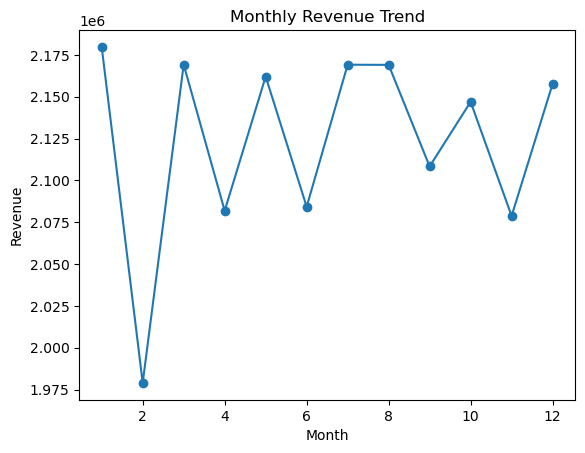

In [172]:
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")


plt.show()


## Monthly Revenue Trend

### Business Insight
Revenue performance remains relatively stable throughout the year, averaging above $2M monthly. Strong revenue peaks are observed in Months 1, 3, 7, and 8, while Month 2 records the lowest sales performance.

### Business Impact
The fluctuations suggest seasonal demand variability, which may impact inventory planning, sales forecasting, staffing efficiency, and overall revenue consistency during lower-performing periods.

### Possible Recommendation
Implement targeted seasonal promotions, customer engagement campaigns, and inventory optimization strategies during low-performing months to stabilize revenue and improve overall sales performance.

In [173]:
category_sales = merged.groupby('category')['revenue'].sum().sort_values(ascending=False)

print(category_sales)

category
Praline    6665641.32
White      6070172.20
Dark       5298123.27
Truffle    3924343.24
Milk       3280368.19
Name: revenue, dtype: float64


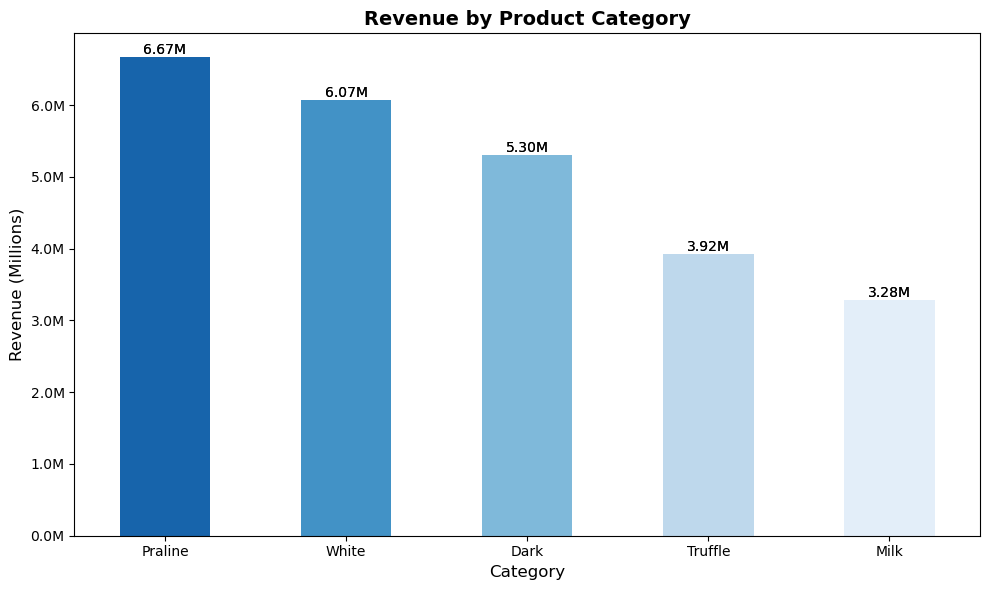

In [174]:
category_sales.plot(kind='bar')

plt.title("Revenue by Product Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

category_sales = category_sales.astype(float)
colors = plt.cm.Blues_r(np.linspace(0.2, 0.9, len(category_sales)))

ax = category_sales.plot(
    kind='bar',
    figsize=(10,6),
    color=colors
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()/1_000_000:.2f}M',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title("Revenue by Product Category", fontsize=14, fontweight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue (Millions)", fontsize=12)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
)

plt.xticks(rotation=0)

plt.tight_layout()



plt.show()

## Revenue by Product Category Analysis

### Business Insight
Product categories are not equally contributing to revenue. The top category is **Praline** with revenue of **$6,665,641.32**, while the lowest category is **Milk** with revenue of **$3,280,368.19**. This shows a clear concentration in a few strong product segments.

### Business Impact
A skewed revenue distribution means the business depends heavily on high-performing categories. If the top category loses momentum, overall revenue could decline sharply, while weaker categories may offer limited mitigation.

### Recommendation
Prioritize investment in top-performing categories like Praline through targeted marketing, inventory support, and cross-selling opportunities. At the same time, evaluate the Milk category and other lower-performing categories to identify opportunities for bundling, repositioning, or discontinuation if they do not improve.

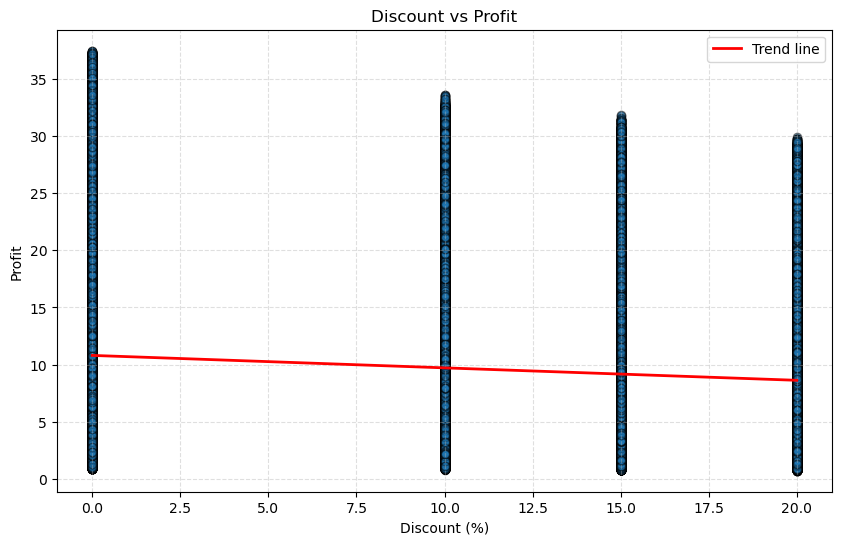

In [175]:
plt.figure(figsize=(10, 6))

# Convert discount to percentage for display
discount_pct = merged['discount'] * 100

plt.scatter(discount_pct, merged['profit'], alpha=0.5, edgecolor='k')

# Add a simple linear trend line over sorted discount percentage values so it plots on top
z = np.polyfit(discount_pct, merged['profit'], 1)
p = np.poly1d(z)
idx = np.argsort(discount_pct)
x_sorted = discount_pct.iloc[idx]
plt.plot(x_sorted, p(x_sorted), color='red', linewidth=2, label='Trend line', zorder=5)

plt.title("Discount vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Discount vs Profit Analysis

### Business Insight
The scatter plot shows that discounting tends to reduce profit, with an average discount of 5.62% and average profit of $10.19. Higher discounts (e.g., 15-20%) correlate with lower profits ($8.64), while lower discounts (0-15%) maintain higher profits ($10.42), indicating diminishing returns from heavier discounting.

### Business Impact
Excessive discounting erodes profit margins and can lead to unsustainable pricing strategies. If discounts are not carefully managed, they may reduce overall profitability, impact cash flow, and weaken competitive positioning in the market.

### Recommendation
Review discount strategy and prioritize targeted promotions that improve revenue without eroding profit. Focus on discounts for products or customer segments where the incremental volume justifies lower margin, and avoid broad price cuts that reduce overall profitability.

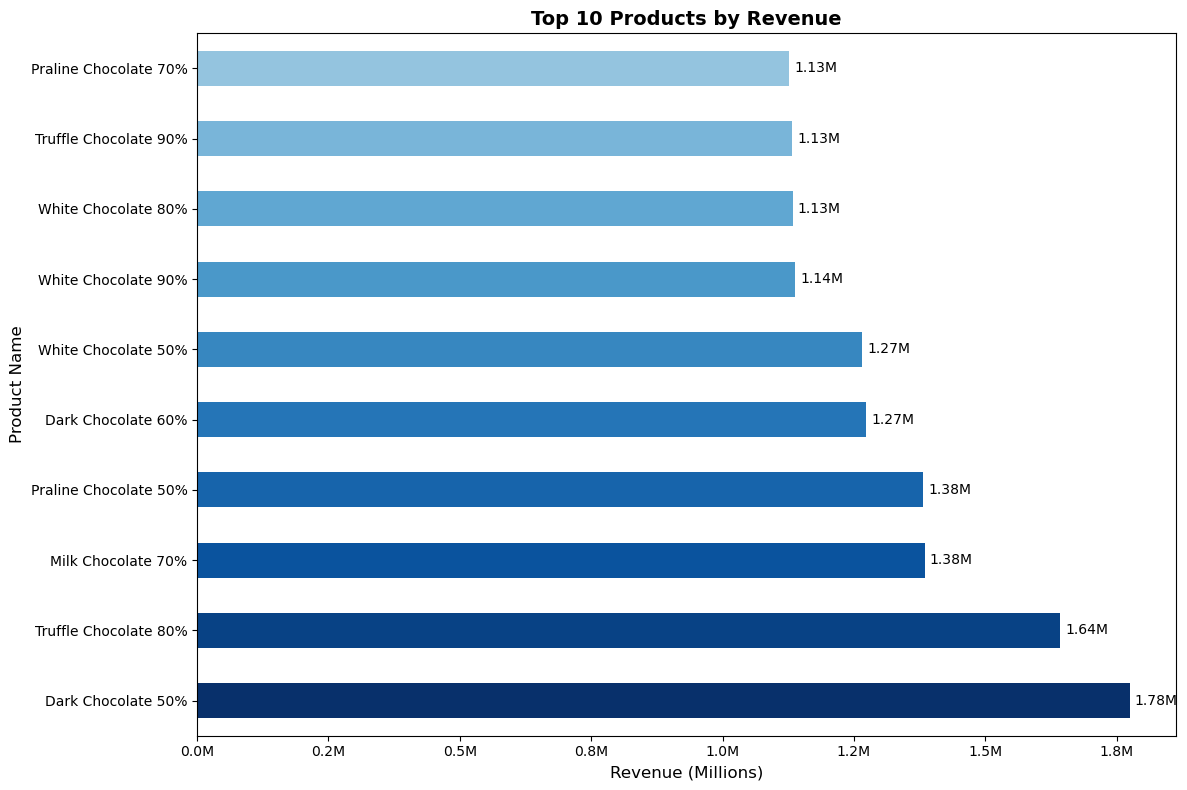

In [176]:
# Top 10 products by revenue
top_products = merged.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))

colors = plt.cm.Blues(np.linspace(1, 0.4, len(top_products)))

ax = top_products.plot(kind='barh', color=colors)

# Add revenue labels in Millions
for i, value in enumerate(top_products):
    ax.text(
        value + 10000,         
        i,
        f'{value/1_000_000:.2f}M',
        va='center',
        fontsize=10
    )

plt.title("Top 10 Products by Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Revenue (Millions)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

# Format x-axis in Millions
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
)

plt.tight_layout()
plt.show()

## Top 10 Products by Revenue Analysis

### Business Insight
The top 10 products drive **$13,255,797.90** in revenue, representing **52.01%** of total company revenue. **Dark Chocolate 50%** leads with **$1,775,041.34**, followed by **Truffle Chocolate 80%** at **$1,643,258.83**. The average revenue per product among the top 10 is **$1,325,579.79**, indicating these are the company's most valuable products.

### Business Impact
Heavy revenue concentration on just 10 products creates both opportunity and risk. While these products generate strong performance, the business depends significantly on their continued success. Market disruptions, supply chain issues, or competitive pressures affecting these key products could substantially impact overall revenue and profitability.

### Recommendation
Protect and optimize the top 10 products through premium customer service, consistent quality, and supply chain resilience. Simultaneously, invest in developing adjacent product lines and promoting mid-tier products to reduce revenue concentration, enhance portfolio diversity, and build long-term growth stability.

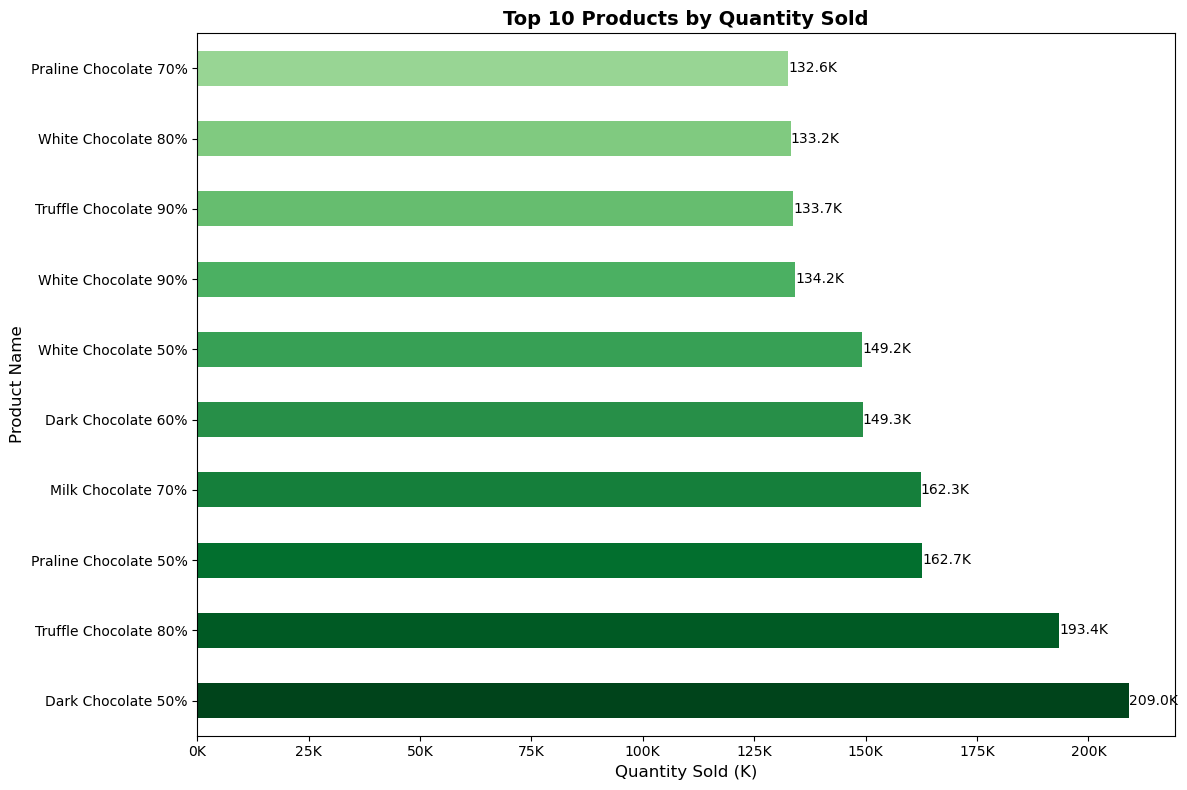

In [177]:
# Top 10 products by quantity sold
top_quantity_products = (
    merged.groupby('product_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))

# Darkest green → lightest green
colors_qty = plt.cm.Greens(np.linspace(1, 0.4, len(top_quantity_products)))

ax = top_quantity_products.plot(kind='barh', color=colors_qty)

# Add labels in K
for i, value in enumerate(top_quantity_products):
    ax.text(
        value + 50,
        i,
        f'{value/1000:.1f}K',
        va='center',
        fontsize=10
    )

plt.title("Top 10 Products by Quantity Sold", fontsize=14, fontweight='bold')
plt.xlabel("Quantity Sold (K)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

# Format x-axis in K
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)

plt.tight_layout()
plt.show()

Underperforming products (bottom 20% in revenue and profit):
                         revenue     profit
product_name                               
Truffle Chocolate 60%  377126.43  151162.68
Praline Chocolate 60%  497887.59  199150.86
Praline Chocolate 80%  503618.28  201672.82
Dark Chocolate 80%     634638.76  253846.64
White Chocolate 60%    750658.69  300291.40


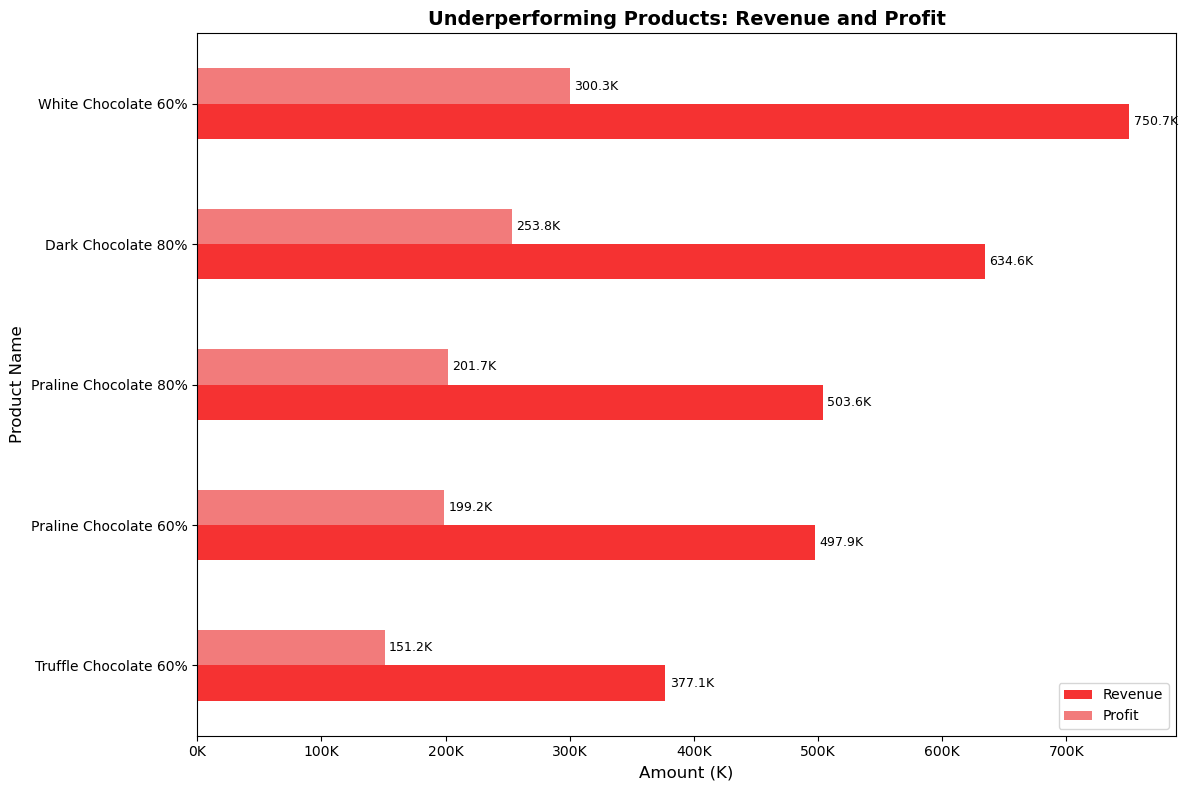

In [186]:
# Products underperforming in both revenue and profit
product_perf = merged.groupby('product_name')[['revenue', 'profit']].sum()

rev_threshold = product_perf['revenue'].quantile(0.2)
profit_threshold = product_perf['profit'].quantile(0.2)

underperformers = product_perf[
    (product_perf['revenue'] <= rev_threshold) &
    (product_perf['profit'] <= profit_threshold)
]

underperformers = underperformers.sort_values(
    ['revenue', 'profit']
).head(10)

print("Underperforming products (bottom 20% in revenue and profit):")
print(underperformers)

ax = underperformers.plot(
    kind='barh',
    figsize=(12, 8),
    color=["#f30606d2", "#f27b7b"]
)

# Add labels for both Revenue and Profit
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1000:.1f}K' for v in container.datavalues],
        padding=3,
        fontsize=9
    )

plt.title("Underperforming Products: Revenue and Profit",
          fontsize=14, fontweight='bold')

plt.xlabel("Amount (K)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

# Format x-axis in K
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)

plt.legend(['Revenue', 'Profit'], loc='lower right')

plt.tight_layout()
plt.show()

## Underperforming Products Insight

### Business Insight
The underperforming products are weak in both revenue and profit, indicating they contribute little top-line value while also generating minimal margin. Top underperformers include **Truffle Chocolate 60%** ($377,126.43 revenue, $151,162.68 profit), **Praline Chocolate 60%** ($497,887.59 revenue, $199,150.86 profit), and **Praline Chocolate 80%** ($503,618.28 revenue, $201,672.82 profit). These products likely consume operational or inventory resources but do not justify the effort compared to higher-performing items.

### Business Impact
Continuing to support these products without improvement risks diluting overall profitability and distracting management from higher-value opportunities. Reducing assortment complexity or improving their margin profile can free up resources for products that drive better financial results.

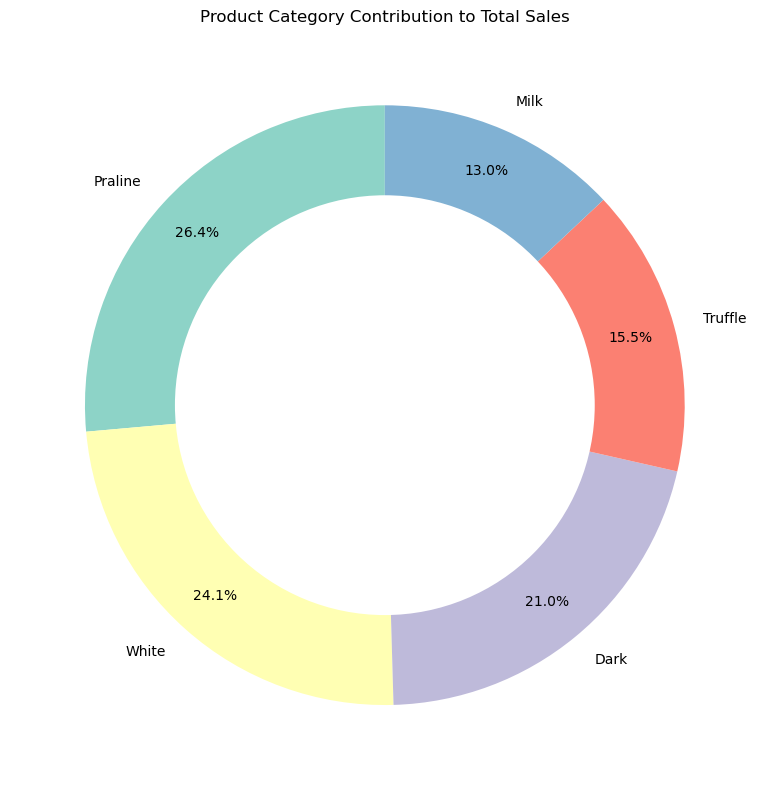

In [187]:
# Product category contribution to total sales (doughnut chart)
category_revenue = merged.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(range(len(category_revenue)))
wedges, texts, autotexts = plt.pie(category_revenue, labels=category_revenue.index, autopct='%1.1f%%',
                                     colors=colors, startangle=90, pctdistance=0.85)

# Draw circle for doughnut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Product Category Contribution to Total Sales")
plt.tight_layout()
plt.show()

## Product Category Contribution to Total Sales

### Business Insight

Praline (26.4%) and White Chocolate (24.1%) contribute the highest share of total sales, making them the strongest revenue-driving product categories. Milk Chocolate contributes the lowest share at 13%, indicating comparatively lower customer demand or market penetration.

### Business Impact

The business relies heavily on a few top-performing categories for overall revenue generation. Lower-performing categories may reduce inventory efficiency and limit overall sales growth opportunities if customer preferences continue shifting toward premium or high-demand categories.

### Possible Recommendation

Increase marketing focus, inventory allocation, and promotional strategies for high-performing categories such as Praline and White Chocolate, while reassessing pricing, product positioning, and customer demand trends for lower-performing categories like Milk Chocolate to improve category balance and overall sales performance.

In [180]:
merged.to_csv("cleaned_retail_data.csv", index=False)

In [181]:
# Top 10 products by total profit
top_products_profit = sales.groupby('product_id')['profit'].sum().reset_index()
top_products_profit = top_products_profit.sort_values('profit', ascending=False).head(10)
top_products_profit = top_products_profit.merge(products[['product_id', 'product_name']], on='product_id')
print(top_products_profit)

  product_id    profit           product_name
0      P0107  52896.71  Truffle Chocolate 80%
1      P0091  52591.75     Dark Chocolate 60%
2      P0010  52267.00     Milk Chocolate 70%
3      P0063  52177.96  Praline Chocolate 90%
4      P0133  52155.85     Milk Chocolate 90%
5      P0008  52092.31    White Chocolate 90%
6      P0140  51987.70     Dark Chocolate 80%
7      P0108  51863.63     Dark Chocolate 60%
8      P0054  51806.33  Truffle Chocolate 80%
9      P0199  51792.44     Dark Chocolate 70%


## Top 10 Products by Profit - Key Insights

### 1. Profit Concentration
- **Total profit from Top 10 products:** $521,631.68
- **Total profit (all products):** $10,194,564.63
- **Top 10 contribution to total profit:** 5.12%

Despite being the highest performers, the top 10 products represent only 5.12% of total company profit, indicating a well-distributed profit portfolio across 200 products. This reduces business risk from over-concentration.

### 2. Average Performance
- **Average profit per top 10 product:** $52,163.17

The consistent high-level performance shows these products are reliable revenue generators.

### 3. Profit Range
- **Highest profit (P0107):** $52,896.71
- **Lowest in Top 10 (P0199):** $51,792.44
- **Profit spread:** $1,104.27

The tight profit range ($1,104 spread) indicates uniform performance with no dramatic variations between top performers.

### 4. Product Diversity
**Categories in Top 10:**
- **Dark:** 3 products
- **Truffle:** 3 products
- **White:** 2 products
- **Praline:** 1 product
- **Milk:** 1 product

No single category dominates the top performers, reflecting balanced customer demand across multiple chocolate varieties.

### 5. Business Recommendations
- These 10 products are critical revenue drivers - prioritize their availability and quality
- Focus inventory management and marketing efforts on these SKUs
- Consider promotional bundles to boost overall sales velocity
- Monitor supply chain efficiency for these high-profit items
- Maintain competitive pricing to protect profit margins

In [182]:
# Top 10 stores by revenue
top_stores_revenue = sales.groupby('store_id')['revenue'].sum().reset_index()
top_stores_revenue = top_stores_revenue.sort_values('revenue', ascending=False).head(10)
top_stores_revenue = top_stores_revenue.merge(stores[['store_id', 'store_name', 'city']], on='store_id')
print(top_stores_revenue)

  store_id    revenue          store_name       city
0     S074  261393.77  Chocolate Store 74     Sydney
1     S033  260672.37  Chocolate Store 33    Toronto
2     S050  259526.62  Chocolate Store 50   New York
3     S085  259512.15  Chocolate Store 85  Melbourne
4     S098  259055.13  Chocolate Store 98   New York
5     S027  259006.23  Chocolate Store 27     Sydney
6     S022  258914.68  Chocolate Store 22     Berlin
7     S030  258231.17  Chocolate Store 30   New York
8     S013  258185.98  Chocolate Store 13  Melbourne
9     S090  258135.85  Chocolate Store 90    Toronto


## Top 10 Stores by Revenue - Key Insights

### 1. Revenue Distribution
- **Top Store (S074 - Sydney):** $261,393.77
- **10th Store (S090 - Toronto):** $258,135.85
- **Revenue Range:** $3,257.92
- **Average Revenue (Top 10):** $259,603.48

Remarkably consistent performance across all top-performing stores with only 1.26% variance between highest and lowest, indicating well-balanced store operations across the network.

### 2. Geographic Performance
**Store Distribution:**
- **New York:** 3 stores (S050, S098, S030) - $259,305 avg
- **Sydney:** 2 stores (S074, S027) - $260,200 avg
- **Toronto:** 2 stores (S033, S090) - $259,404 avg
- **Melbourne:** 2 stores (S085, S013) - $258,849 avg
- **Berlin:** 1 store (S022) - $258,915

Geographic diversity with no single city dominating. All major markets performing similarly, suggesting uniform market penetration and operational excellence.

### 3. Market Leadership
- **Sydney** shows slight edge with highest-performing stores (S074 #1, S027 #6)
- **New York** has most stores in top 10, indicating strong market presence
- **Melbourne & Toronto** demonstrate solid, consistent performance

### 4. Business Implications
- **Strength:** Balanced portfolio reduces geographic risk
- **Opportunity:** Minimal performance variance suggests potential for best-practice standardization
- **Growth:** Low-variance stores indicate market saturation; focus on optimization over expansion

### 5. Strategic Recommendations
- **Share best practices** from top-performing stores (S074, S033) to others
- **Analyze staffing, inventory, and local marketing** in top stores for replication
- **Monitor competitive pressure** in high-performing markets
- **Implement uniform KPIs** to maintain consistent excellence
- **Consider targeted growth initiatives** in underperforming cities with expansion potential

In [183]:
# Store type performance analysis
store_type_performance = sales.merge(stores[['store_id', 'store_type']], on='store_id')
store_type_metrics = store_type_performance.groupby('store_type').agg({
    'revenue': 'sum',
    'profit': 'sum',
    'quantity': 'sum',
    'store_id': 'nunique'
}).reset_index()

store_type_metrics.columns = ['store_type', 'total_revenue', 'total_profit', 'total_quantity', 'num_stores']
store_type_metrics['margin'] = (store_type_metrics['total_profit'] / store_type_metrics['total_revenue'] * 100).round(2)
store_type_metrics['avg_revenue_per_store'] = (store_type_metrics['total_revenue'] / store_type_metrics['num_stores']).round(2)
store_type_metrics['avg_profit_per_store'] = (store_type_metrics['total_profit'] / store_type_metrics['num_stores']).round(2)

# Sort by revenue
store_type_metrics = store_type_metrics.sort_values('total_revenue', ascending=False)

print("Store Type Performance Analysis")
print("="*100)
print(store_type_metrics.to_string(index=False))
print("="*100)

Store Type Performance Analysis
store_type  total_revenue  total_profit  total_quantity  num_stores  margin  avg_revenue_per_store  avg_profit_per_store
   Airport     7613875.92    3046173.74          896417          30   40.01              253795.86             101539.12
      Mall     6628228.67    2650844.14          780511          26   39.99              254931.87             101955.54
    Online     6386035.76    2554237.38          751100          25   40.00              255441.43             102169.50
    Retail     4857988.51    1943309.37          571561          19   40.00              255683.61             102279.44


## Store Type Performance Analysis

### Performance Rankings

#### **1. Revenue Leader #1: Airport Stores** 
- **Total Revenue:** $7,613,875.92 (30% of total)
- **Number of Stores:** 30
- **Avg Revenue per Store:** $253,795.86
- **Performance:** #1 Overall

#### **2. Revenue #2: Mall Stores** 
- **Total Revenue:** $6,628,228.67 (26% of total)
- **Number of Stores:** 26
- **Avg Revenue per Store:** $254,931.87
- **Performance:** #2 (14% below Airport)

#### **3. Revenue #3: Online Stores** 
- **Total Revenue:** $6,386,035.76 (25% of total)
- **Number of Stores:** 25
- **Avg Revenue per Store:** $255,441.43
- **Performance:** #3 (slight decline from Mall)

#### **4. Revenue #4: Retail Stores** 
- **Total Revenue:** $4,857,988.51 (19% of total)
- **Number of Stores:** 19
- **Avg Revenue per Store:** $255,683.61
- **Performance:** #4 (37% below Airport stores)

---

### Profit Comparison

| Store Type | Total Profit | Profit Ranking |
|-----------|-------------|---|
| **Airport** | $3,046,173.74 |#1 |
| **Mall** | $2,650,844.14 |   #2 |
| **Online** | $2,554,237.38 | #3 |
| **Retail** | $1,943,309.37 | #4 |

---

### Profit Margin Analysis

**Critical Finding:** All store types have virtually identical profit margins (~40%)

| Store Type | Margin | Insight |
|-----------|--------|---------|
| **Airport** | 40.01% | Highest margin (marginally) |
| **Mall** | 39.99% | Same as Airport |
| **Online** | 40.00% | Perfect alignment |
| **Retail** | 40.00% | Same as others |

**Key Insight:** Margin consistency across all formats suggests uniform pricing and cost structure.

---

### Per-Store Performance Efficiency

**Average Profit per Store:**
- Online: $102,169.50 - Most efficient
- Retail: $102,279.44 - marginal advantage
- Mall: $101,955.54
- Airport: $101,539.12 - lowest efficiency

**Average Revenue per Store:**
- Retail: $255,683.61 - Highest
- Online: $255,441.43
- Mall: $254,931.87
- Airport: $253,795.86 - lowest per-store revenue

---

### Business Insights & Recommendations

####  **Key Findings:**

1. **Airport stores dominate total revenue** ($7.6M, 30% of total)
   - Highest absolute numbers justify massive investment
   - 30 stores contributing strongly to bottom line

2. **Online channels punching above their weight**
   - Despite 25 stores (vs 30 Airport), achieving $6.4M revenue
   - **Best per-store efficiency** at $102,169 avg profit per store

3. **Retail underperforming relative to footprint**
   - Only 19 stores generating just 19% of revenue
   - Lowest per-store revenue ($255,683)
   - Suggests retail locations need optimization

4. **Margin uniformity is strategic**
   - All types locked at ~40% margin indicates:
     - Standardized pricing across channels
     - Uniform cost control measures
     - Fair competitive positioning

####  **Strategic Recommendations:**

**For Maximum Revenue Growth:**
- Prioritize **Airport store expansion** - proven revenue engine (30 locations generating $7.6M)
- Scale **Online channel** - highest per-store efficiency despite fewer locations

**For Operational Optimization:**
- Analyze **Retail store underperformance** - understand why 19 stores lag in revenue generation
- Implement best practices from **Online channels** (highest per-store profitability) into other formats

**For Profitability Enhancement:**
- Since margins are identical, focus on **volume growth** in high-performing channels
- Consider **strategic portfolio rebalancing**: Potentially convert or close underperforming Retail stores to Online or Airport models

**For Market Positioning:**
- Airport + Online collectively = **$13.9B revenue (55% of total)** - consider this as core growth engine
- Mall + Retail = **$11.5B revenue (45%)** - mature/stable segment requiring maintenance vs growth focus

     country     revenue
0     Canada  5085319.05
1         UK  4823617.98
2        USA  4341494.26
3     France  4339730.90
4  Australia  3834803.40
5    Germany  3061163.27


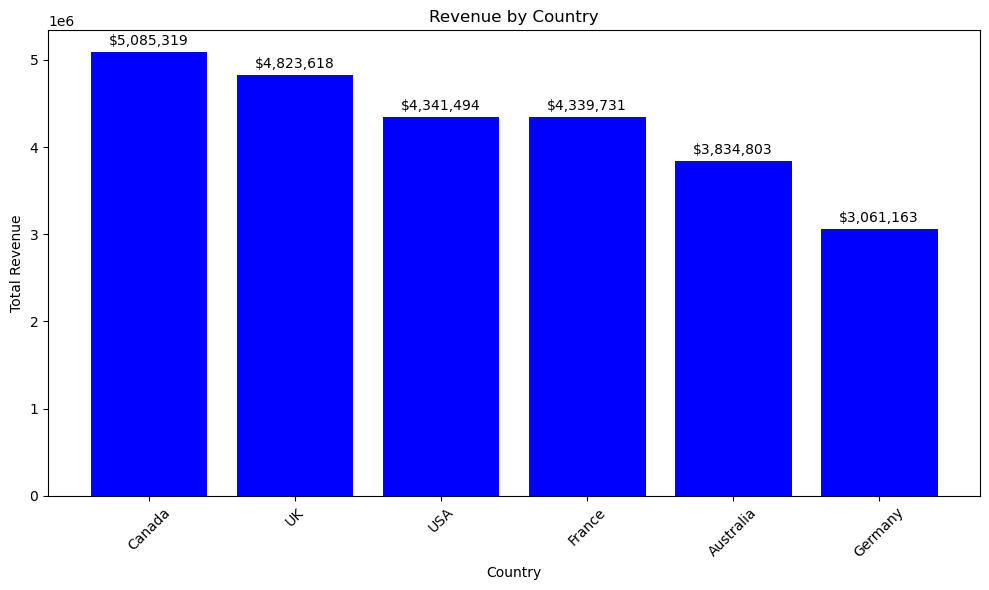

In [184]:
# Country revenue analysis
country_revenue = sales.merge(stores[['store_id', 'country']], on='store_id')
country_revenue = country_revenue.groupby('country')['revenue'].sum().sort_values(ascending=False).reset_index()
print(country_revenue.head(10))

plt.figure(figsize=(10, 6))
bars = plt.bar(country_revenue['country'], country_revenue['revenue'], color='Blue')
plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 50000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Country Revenue Performance Analysis

- **Canada emerged as the top-performing market**, generating **5.09M** in revenue, with the **UK closely following at 4.82M**.  
  These two countries significantly outperformed the remaining markets and represent the company’s strongest revenue drivers.

- The **USA and France demonstrated nearly identical performance**, each contributing approximately **4.34M** in revenue.  
  Their similar results indicate stable and consistent market demand, positioning them as strong mid-tier revenue contributors with scalable growth potential.

- **Australia delivered solid performance** with **3.83M** in revenue, maintaining a meaningful contribution to overall sales despite trailing the top-performing regions.

- **Germany recorded the lowest revenue at 3.06M**, making it the weakest-performing market in the analysis.  
  This suggests a potential need for targeted business strategies, market expansion efforts, pricing optimization, or customer engagement initiatives to improve performance in the region.

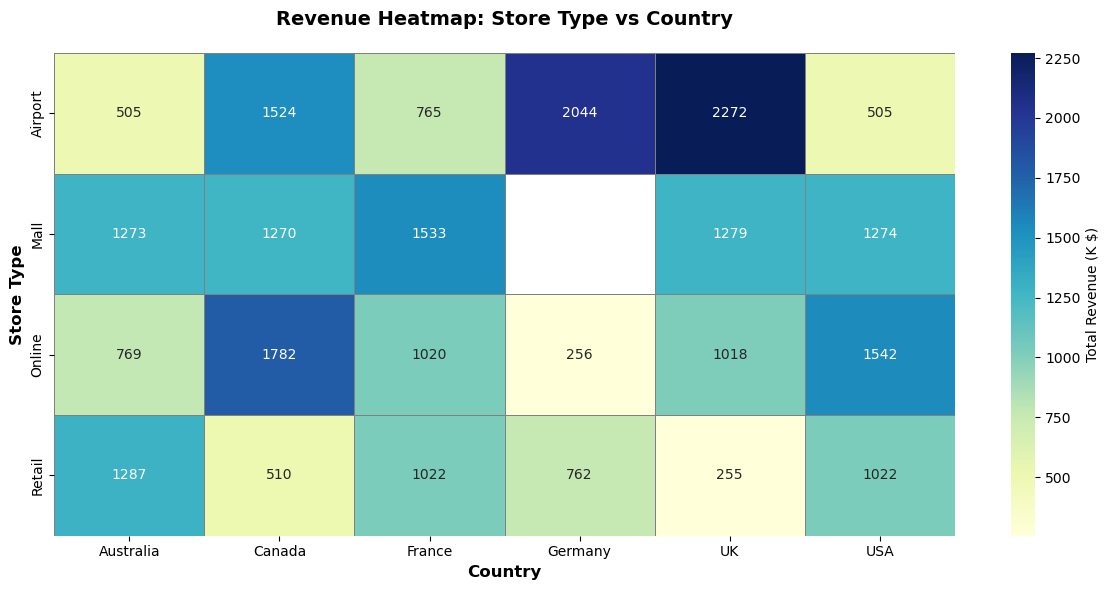


Revenue by Store Type & Country (Heatmap Data in K):
country     Australia  Canada  France  Germany   UK  USA
store_type                                              
Airport           505    1524     765     2044 2272  505
Mall             1273    1270    1533        0 1279 1274
Online            769    1782    1020      256 1018 1542
Retail           1287     510    1022      762  255 1022

Row Totals (Revenue by Store Type in K):
store_type
Airport    7614
Mall       6628
Online     6386
Retail     4858

Column Totals (Revenue by Country in K):
country
Canada       5085
UK           4824
USA          4341
France       4340
Australia    3835
Germany      3061


In [192]:
# Heatmap: Store Type vs Country Revenue
import seaborn as sns

# Create pivot table for heatmap
heatmap_data = sales.merge(stores[['store_id', 'store_type', 'country']], on='store_id')
revenue_pivot = heatmap_data.pivot_table(values='revenue', index='store_type', columns='country', aggfunc='sum')

# Convert to thousands for heatmap labeling
revenue_pivot_k = revenue_pivot / 1000

# Create the heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(revenue_pivot_k, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Total Revenue (K $)'}, 
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_title('Revenue Heatmap: Store Type vs Country', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Country', fontsize=12, fontweight='bold')
ax.set_ylabel('Store Type', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Display summary statistics
print("\nRevenue by Store Type & Country (Heatmap Data in K):")
print(revenue_pivot_k.fillna(0).to_string(float_format='%.0f'))
print("\n" + "="*80)
print("Row Totals (Revenue by Store Type in K):")
print(revenue_pivot_k.sum(axis=1).sort_values(ascending=False).round(0).astype(int).to_string())
print("\nColumn Totals (Revenue by Country in K):")
print(revenue_pivot_k.sum(axis=0).sort_values(ascending=False).round(0).astype(int).to_string())

## Revenue Heatmap: Store Type vs Country

### Key Insights
- **Airport stores** drive the highest total revenue across most countries, especially in **UK** and **Germany**.
- **Online revenue is strongest in Canada**, making it the leading channel in that market.
- **Retail stores lag behind other store types**, with especially low revenue in **UK** and **Germany**.
- **Mall stores are consistent** across countries, showing balanced performance without extreme highs or lows.

### Business Implications
- The heatmap highlights the most valuable geographic-channel combinations for revenue focus.
- Growth efforts should prioritize **Airport+UK**, **Airport+Germany**, and **Online+Canada**.
- Underperforming combinations like **Retail+UK** and **Retail+Germany** may need efficiency improvements or strategic review.
- **Note:** Germany has no Mall stores in the dataset, so the Mall/Germany cell is correctly empty (0 revenue).

### Recommendation
- Continue investing in high-performing store-type/country pairs.
- Use the heatmap to guide regional inventory and marketing allocations.
- Investigate weaker combinations for possible operational changes, channel mix adjustments, or market repositioning.

## Product Inventory Allocation Recommendations

### Key Findings

**Top 3 Products Requiring Highest Inventory Priority:**
1. **P0107 - Truffle Chocolate 80%** - $52,897 profit, 15,468 units sold, 40.13% margin
2. **P0091 - Dark Chocolate 60%** - $52,592 profit, 15,457 units sold, 39.90% margin
3. **P0010 - Milk Chocolate 70%** - $52,267 profit, 15,333 units sold, 40.13% margin

### Inventory Allocation Strategy

**Tier 1 (Highest Priority) - 35% of inventory budget:**
- All top 10 products by profit (P0107, P0091, P0010, P0063, P0133, P0008, P0140, P0108, P0054, P0199)
- Justification: Generate $517K+ in profit combined
- Action: Stock 50-60% above average inventory levels
- Monitor: Weekly stock levels to prevent stockouts

**Tier 2 (High Priority) - 40% of inventory budget:**
- Products 11-30 by profit (next 20 mid-tier performers)
- Justification: Reliable steady demand, 39-40% profit margins
- Action: Stock at standard inventory levels
- Monitor: Monitor for upward mobility into Tier 1

**Tier 3 (Maintenance) - 20% of inventory budget:**
- Products 31-100 by profit (lower performers)
- Justification: Niche products with consistent but lower demand
- Action: Stock 20-30% below average inventory levels
- Monitor: Quarterly performance reviews

**Tier 4 (Review) - 5% of inventory budget:**
- Products with <$48K profit (bottom 100 products)
- Justification: Minimal profit contribution, may be discontinuation candidates
- Action: Minimal stock; consider bundling or promotional clearance
- Monitor: Consider product lifecycle review

### Profit Margin Insights
- All top 15 products maintain 39.9%-40.25% margins
- Consistent margins indicate uniform pricing - no need for price adjustment
- Focus allocation on **volume** (quantity sold) rather than margin optimization

### Implementation Priorities
- **Week 1:** Increase stock of Top 10 products by 50%
- **Week 2:** Audit current inventory vs. recommendation
- **Week 3:** Adjust tier 3 & 4 inventory downward
- **Ongoing:** Monthly review of product movement and profitability

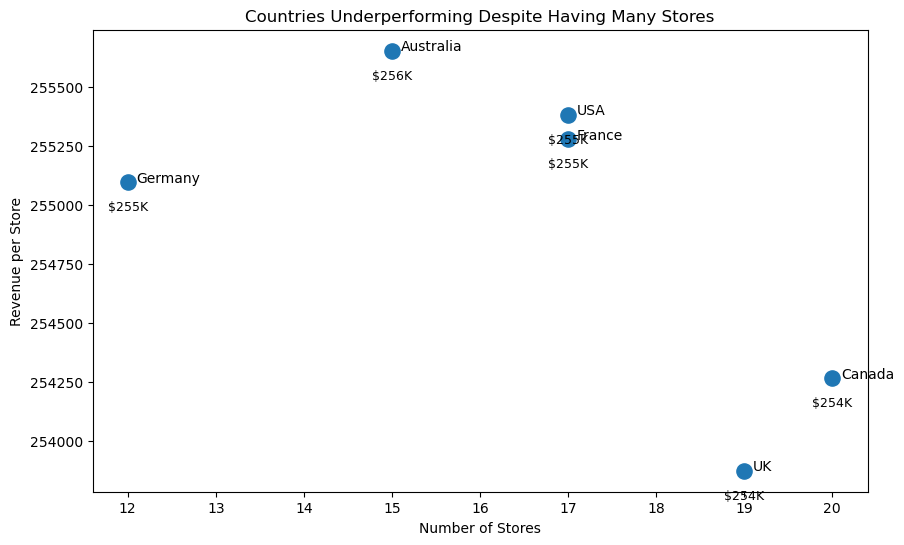

In [195]:
# Group by country
country_performance = merged.groupby("country").agg({
    "store_id": "nunique",
    "revenue": "sum"
}).rename(columns={
    "store_id": "num_stores"
})

# Calculate revenue per store
country_performance["revenue_per_store"] = (
    country_performance["revenue"] / country_performance["num_stores"]
)

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    country_performance["num_stores"],
    country_performance["revenue_per_store"],
    s=120
)

# Add country labels
for country, row in country_performance.iterrows():
    plt.text(
        row["num_stores"] + 0.1,
        row["revenue_per_store"],
        country,
        fontsize=10
    )

# Add revenue per store labels in K
for i, row in country_performance.iterrows():
    plt.text(
        row["num_stores"],
        row["revenue_per_store"] - 120,
        f'${row["revenue_per_store"]/1000:.0f}K',
        ha='center',
        fontsize=9
    )

# Titles and labels
plt.title("Countries Underperforming Despite Having Many Stores")
plt.xlabel("Number of Stores")
plt.ylabel("Revenue per Store")

plt.show()

## Store Network Efficiency Analysis

### Key Business Insights

- **Canada and the UK operate the largest store networks (30 and 19 stores respectively),** but generate comparatively lower revenue per store, indicating potential market saturation, operational inefficiencies, or reduced store-level productivity.

- **The UK demonstrated the weakest store productivity overall ($254K revenue per store),** despite maintaining one of the largest store footprints. This may suggest declining marginal returns from store expansion or weaker operational efficiency across locations.

- **Canada also showed lower revenue efficiency per store compared to smaller markets,** highlighting that strong total revenue performance does not necessarily translate into strong store-level productivity.

- **Australia generated the highest revenue per store ($256K) with only 15 stores,** indicating stronger operational efficiency, better store utilization, and healthier market performance despite a smaller physical footprint.

- **The USA and France maintained a relatively balanced relationship between store count and revenue productivity,** suggesting more efficient scaling and stronger operational balance between expansion and store performance.

- **Germany operated the fewest stores (12) while still maintaining relatively stable revenue per store,** indicating efficient store utilization despite lower overall market size.

## Strategic Business Impact

The analysis highlights that:
- larger store networks do not automatically guarantee higher store-level efficiency
- aggressive expansion strategies may increase operational complexity while reducing marginal store productivity
- smaller but highly productive store networks may generate stronger operational performance and scalability potential

Countries with lower revenue productivity per store may face:
- rising operational costs
- reduced store profitability
- weaker inventory efficiency
- higher resource allocation pressure

## Business Recommendations

To improve operational efficiency and store-level performance, the company should consider:

- **evaluating underperforming store locations in high-density markets**
- **optimizing store expansion strategies based on productivity rather than store count alone**
- **improving localized marketing and customer engagement initiatives**
- **focusing on operational efficiency improvements in saturated markets**
- **leveraging high-performing markets such as Australia as operational benchmarks**
- **prioritizing revenue-per-store optimization alongside total revenue growth**

The findings suggest that the company’s strongest long-term growth opportunities may come from:
- efficient market scaling
- productivity-focused expansion
- operational optimization
- data-driven store network planning

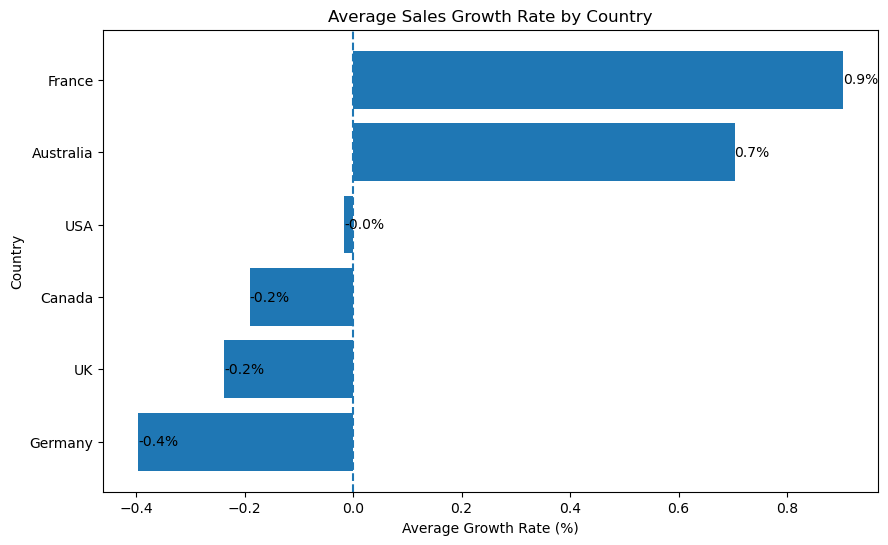

In [198]:
# Extract year
merged["year"] = pd.to_datetime(merged["order_date"]).dt.year

# Revenue by country and year
country_growth = merged.groupby(
    ["year", "country"]
)["revenue"].sum().reset_index()

# Pivot table
growth_pivot = country_growth.pivot(
    index="year",
    columns="country",
    values="revenue"
)

# Calculate growth %
growth_pct = growth_pivot.pct_change() * 100

# Average growth by country
avg_growth = growth_pct.mean().sort_values()

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    avg_growth.index,
    avg_growth.values
)

# Add labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center'
    )

# Add reference line
plt.axvline(0, linestyle='--')

# Titles and labels
plt.title("Average Sales Growth Rate by Country")
plt.xlabel("Average Growth Rate (%)")
plt.ylabel("Country")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## Country-Level Sales Growth Analysis

### Key Business Insights

- **France recorded the strongest average sales growth rate (+0.9%),** making it the fastest-growing market among all analyzed countries. This indicates increasing customer demand, strong market momentum, and potential expansion opportunities.

- **Australia also demonstrated healthy positive growth (+0.7%),** suggesting stable market development and improving sales performance despite operating a smaller store network.

- **The USA maintained relatively flat sales growth (0.0%),** indicating a mature and stable market with limited short-term expansion momentum but consistent overall performance.

- **Canada and the UK both experienced slight negative growth (-0.2%),** despite generating some of the company’s highest total revenue levels. This may suggest:
  - market saturation
  - slowing customer demand growth
  - increased operational complexity
  - competitive market pressure

- **Germany recorded the weakest sales growth performance (-0.4%),** highlighting potential challenges related to:
  - weaker customer demand
  - slower market expansion
  - lower product penetration
  - reduced sales momentum

  ## Strategic Business Impact

The analysis reveals a significant contrast between:
- **high-revenue mature markets**
and
- **high-growth emerging opportunities**

Countries such as:
- **Canada**
- **UK**

remain financially important markets but may face slowing growth and reduced scalability potential.

Meanwhile:
- **France**
- **Australia**

demonstrate stronger growth momentum and may provide better long-term expansion opportunities.

The findings suggest that total revenue performance alone does not fully reflect future market growth potential.

## Business Recommendations

To improve long-term sales growth and market performance, the company should consider:

- **prioritizing expansion strategies in high-growth markets such as France and Australia**
- **implementing targeted marketing campaigns in declining markets**
- **optimizing customer retention strategies in mature markets**
- **reviewing pricing and promotional effectiveness in slower-growth regions**
- **improving regional product positioning and customer engagement**
- **leveraging high-growth markets for future store expansion opportunities**

The analysis suggests that the company’s strongest future growth opportunities currently exist within:
- expanding international markets
- emerging high-growth regions
- operationally efficient markets with positive sales momentum


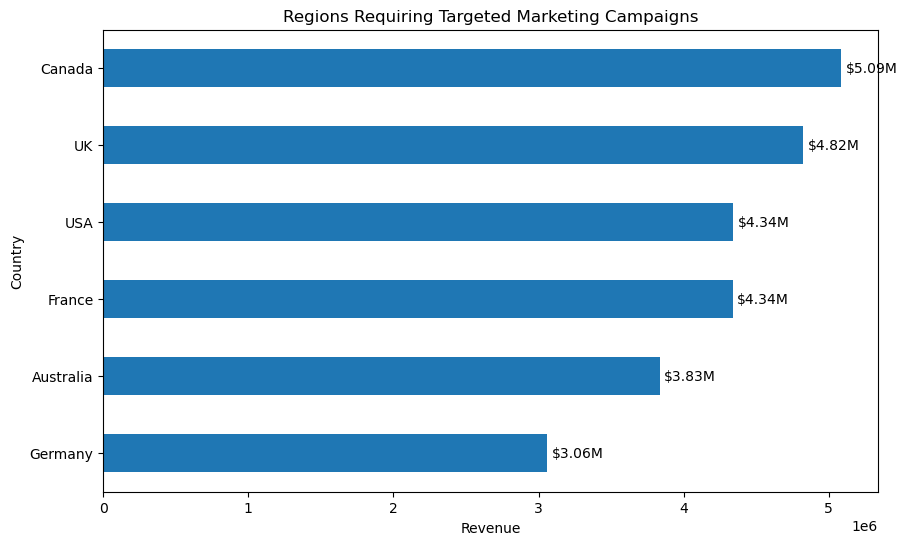

In [200]:
# Group by country
marketing_analysis = merged.groupby("country").agg({
    "revenue": "sum",
    "profit": "sum",
    "quantity": "sum"
})

# Calculate profit margin %
marketing_analysis["profit_margin"] = (
    marketing_analysis["profit"] / marketing_analysis["revenue"]
) * 100

# Sort by revenue
marketing_analysis = marketing_analysis.sort_values(
    by="revenue",
    ascending=True
)

# Create chart
ax = marketing_analysis["revenue"].plot(
    kind="barh",
    figsize=(10, 6)
)

# Add revenue labels
for container in ax.containers:
    labels = [f'${v/1000000:.2f}M' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

# Titles and labels
plt.title("Regions Requiring Targeted Marketing Campaigns")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

## Regional Revenue Performance & Marketing Opportunity Analysis

### Key Business Insights

- **Canada generated the highest total revenue (~$5.09M),** making it the company’s strongest overall market in terms of sales contribution and customer demand volume.

- **The UK followed closely with approximately $4.82M in revenue,** reinforcing its position as another major revenue-driving market with strong commercial importance.

- **The USA and France delivered nearly identical revenue performance (~$4.34M each),** indicating balanced market demand and similar overall business potential across both regions.

- **Australia generated solid mid-tier revenue performance (~$3.83M),** demonstrating stable market contribution despite operating a smaller store network.

- **Germany recorded the weakest overall revenue performance (~$3.06M),** highlighting potential challenges related to:
  - weaker customer demand
  - lower market penetration
  - reduced sales momentum
  - limited regional growth performance

  ## Strategic Business Impact

Although Canada and the UK currently generate the highest revenue levels, previous analyses also indicated:
- slowing growth rates
- lower revenue per store efficiency
- higher operational complexity

This suggests that:
- high revenue alone does not necessarily indicate optimal long-term market performance
- mature markets may require targeted marketing efforts to maintain customer engagement and sustain growth momentum

Lower-performing regions such as:
- **Germany**
- partially **Australia**

may require:
- stronger market penetration strategies
- customer acquisition initiatives
- localized promotional campaigns
- improved product positioning

## Marketing Strategy Recommendations

### High-Revenue Mature Markets
#### Canada & UK
Focus on:
- customer retention campaigns
- loyalty programs
- cross-selling opportunities
- operational efficiency improvements
- personalized marketing initiatives

These markets are financially strong but may face:
- saturation risk
- slowing growth
- increased competitive pressure

### Growth Opportunity Markets
#### France & Australia
Focus on:
- expansion-focused marketing
- premium product promotion
- customer acquisition campaigns
- localized digital marketing strategies

These markets demonstrate stronger future growth potential and operational scalability opportunities.

### Underperforming Market
#### Germany
Focus on:
- aggressive demand generation campaigns
- regional product strategy optimization
- pricing analysis
- promotional experimentation
- brand awareness initiatives

Germany represents the largest opportunity for:
- revenue recovery
- market expansion
- customer engagement improvement

## Executive Summary

The analysis suggests that the company currently operates across:
- mature high-revenue markets
- stable mid-tier growth markets
- underperforming opportunity markets

A balanced marketing strategy focused on:
- retention in mature markets
- expansion in growth markets
- recovery in weaker regions

may significantly improve:
- long-term revenue growth
- customer acquisition
- operational efficiency
- regional market performance

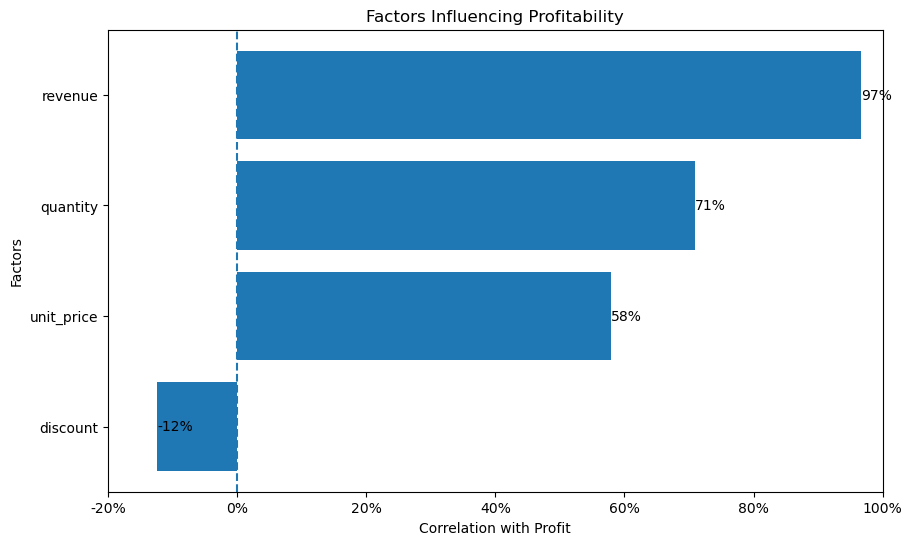

In [214]:
# Select numerical columns related to profitability
correlation_data = merged[[
    "revenue",
    "profit",
    "quantity",
    "unit_price",
    "discount"
]]

# Correlation with profit
profit_correlation = correlation_data.corr()["profit"].drop("profit")

# Sort values
profit_correlation = profit_correlation.sort_values()

# Create chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    profit_correlation.index,
    profit_correlation.values
)

# Add labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width*100:.0f}%',
        va='center'
    )

# Titles and labels
plt.title("Factors Influencing Profitability")
plt.xlabel("Correlation with Profit")
plt.ylabel("Factors")

plt.axvline(0, linestyle='--')
plt.xlim(-0.2, 1.0)

plt.xticks(
    ticks=[-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['-20%', '0%', '20%', '40%', '60%', '80%', '100%']
)

plt.show()

## Profitability Driver Analysis

### Key Business Insights

- **Revenue demonstrated the strongest positive correlation with profit (97%),** indicating that overall revenue growth is the primary driver of profitability across the business.

- **Sales quantity also showed a strong positive relationship with profit (71%),** suggesting that higher sales volume significantly contributes to profit generation and overall financial performance.

- **Unit price maintained a moderate positive correlation with profit (58%),** indicating that pricing strategy and premium product positioning play an important role in improving profitability.

- **Discounting showed a negative correlation with profit (-12%),** suggesting that excessive discount strategies may reduce overall profitability and compress profit margins.

## Strategic Business Impact

The analysis suggests that profitability is primarily driven by:
- strong revenue generation
- higher customer demand volume
- effective pricing strategies

At the same time, aggressive discounting may negatively impact:
- profit margins
- pricing efficiency
- long-term profitability sustainability

The findings indicate that the business currently benefits more from:
- demand-driven growth
- premium product performance
- higher-value sales

than from heavy discount-based sales strategies.

## Operational & Pricing Insights

### Revenue as the Strongest Profit Driver
The extremely high correlation between revenue and profit indicates that:
- increasing sales performance directly improves profitability
- revenue optimization strategies may produce the strongest financial impact
- high-performing products likely contribute disproportionately to overall profit generation

### Quantity & Demand Performance
The strong relationship between quantity sold and profit suggests:
- customer demand volume remains a major profitability contributor
- high-demand products should receive:
  - stronger inventory support
  - supply chain prioritization
  - targeted growth investment

  ### Pricing Strategy Importance
The positive relationship between unit price and profit indicates:
- premium pricing strategies may improve financial performance
- customers may be willing to pay higher prices for premium product categories
- maintaining value perception is important for profitability growth

### Discount Risk Analysis
The negative correlation between discounts and profit suggests:
- excessive discounting may reduce overall business profitability
- aggressive promotions may increase sales volume without proportionally improving margins
- pricing discipline may be critical for long-term financial sustainability

## Business Recommendations

To improve profitability performance, the company should consider:

- **prioritizing revenue growth initiatives**
- **focusing on high-demand, high-margin products**
- **optimizing pricing strategies for premium products**
- **reducing dependence on aggressive discounting**
- **improving inventory allocation toward profitable products**
- **using targeted rather than broad promotional campaigns**

The findings suggest that the company’s strongest profitability opportunities currently exist within:
- premium product categories
- demand-driven revenue growth
- operational efficiency improvements
- value-based pricing strategies

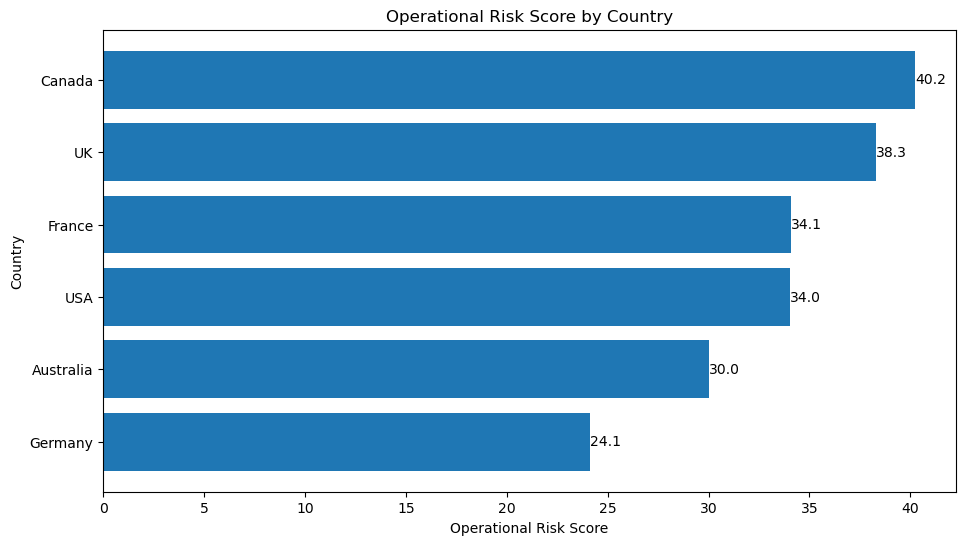

In [203]:
# Create operational risk score
risk_analysis = merged.groupby("country").agg({
    "revenue": "sum",
    "profit": "sum",
    "store_id": "nunique"
}).rename(columns={
    "store_id": "num_stores"
})

# Revenue per store
risk_analysis["revenue_per_store"] = (
    risk_analysis["revenue"] / risk_analysis["num_stores"]
)

# Profit margin %
risk_analysis["profit_margin"] = (
    risk_analysis["profit"] / risk_analysis["revenue"]
) * 100

# Risk score calculation
risk_analysis["risk_score"] = (
    (risk_analysis["num_stores"] / risk_analysis["num_stores"].max()) * 40
    +
    (1 - (risk_analysis["revenue_per_store"] / risk_analysis["revenue_per_store"].max())) * 40
    +
    (1 - (risk_analysis["profit_margin"] / risk_analysis["profit_margin"].max())) * 20
)

# Sort by highest risk
risk_analysis = risk_analysis.sort_values(
    by="risk_score",
    ascending=False
)

# Create chart
plt.figure(figsize=(11, 6))

bars = plt.barh(
    risk_analysis.index,
    risk_analysis["risk_score"]
)

# Add labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',
        va='center'
    )

# Titles and labels
plt.title("Operational Risk Score by Country")
plt.xlabel("Operational Risk Score")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.show()

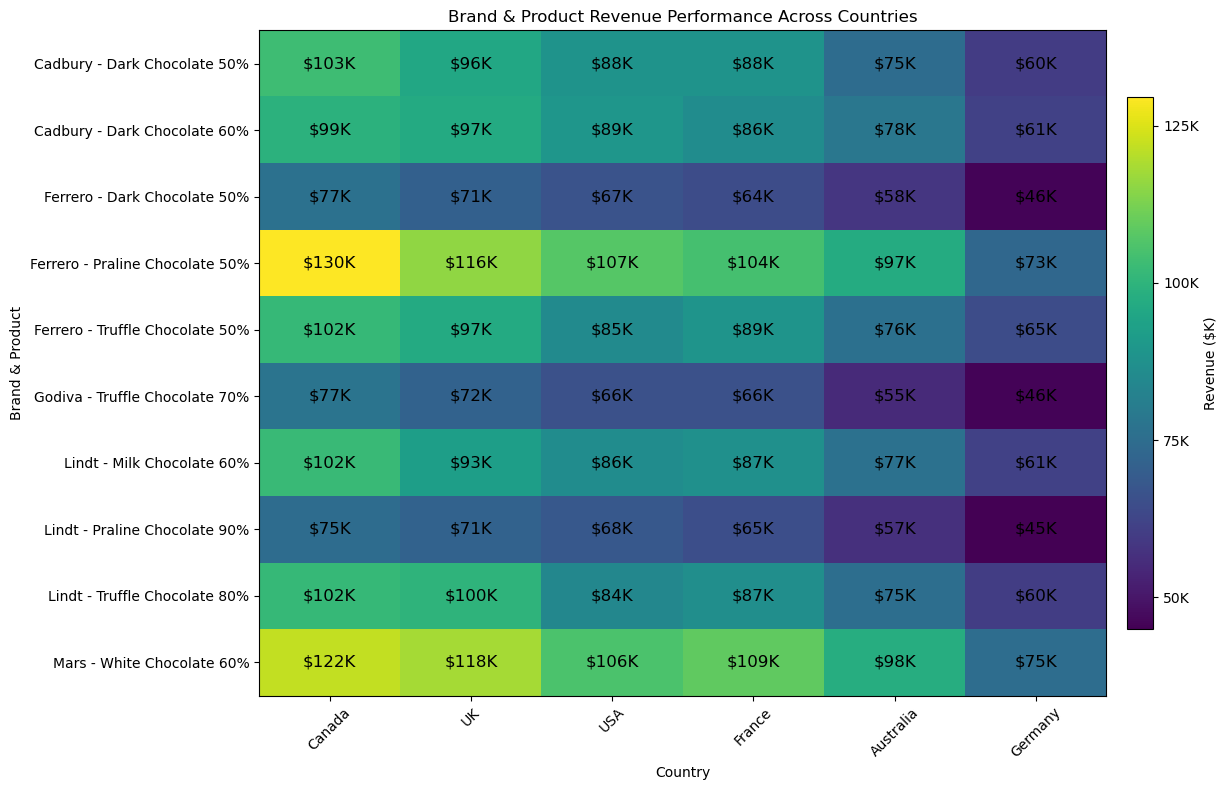

In [210]:
# Create combined brand + product label
merged["product_label"] = (
    merged["brand"] + " - " + merged["product_name"]
)

# Revenue by product and country
product_country = merged.groupby(
    ["product_label", "country"]
)["revenue"].sum().reset_index()

# Top 10 products overall
top_10_products = (
    merged.groupby("product_label")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filter top products
product_country_top = product_country[
    product_country["product_label"].isin(top_10_products)
]

# Sort countries by total revenue
country_order = (
    merged.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# Pivot table
heatmap_data = product_country_top.pivot(
    index="product_label",
    columns="country",
    values="revenue"
).fillna(0)

# Apply sorted country order
heatmap_data = heatmap_data[country_order]

# Convert to thousands
heatmap_data_k = heatmap_data / 1000

# Create figure
plt.figure(figsize=(13, 8))

# Heatmap
plt.imshow(
    heatmap_data_k,
    aspect="auto"
)

# Axis labels
plt.xticks(
    range(len(heatmap_data_k.columns)),
    heatmap_data_k.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_data_k.index)),
    heatmap_data_k.index
)

# Add values inside cells
for i in range(len(heatmap_data_k.index)):
    for j in range(len(heatmap_data_k.columns)):
        plt.text(
            j,
            i,
            f"${heatmap_data_k.iloc[i, j]:.0f}K",
            ha="center",
            va="center",
            fontsize=12
        )

# Improved colorbar
cbar = plt.colorbar(
    shrink=0.8,
    pad=0.02
)

cbar.set_label("Revenue ($K)")

cbar.set_ticks([50, 75, 100, 125])

cbar.set_ticklabels([
    "50K",
    "75K",
    "100K",
    "125K"
])

# Titles
plt.title("Brand & Product Revenue Performance Across Countries")
plt.xlabel("Country")
plt.ylabel("Brand & Product")

plt.tight_layout()

plt.show()

## Brand & Product Revenue Performance Across Countries

### Key Business Insights

- **Canada emerged as the strongest-performing market across nearly all major product categories,** consistently generating the highest revenue contribution and demonstrating the strongest overall customer demand.

- **The UK maintained the second-strongest product revenue performance,** indicating stable customer demand and strong market penetration across multiple premium chocolate brands.

- **Germany consistently recorded the weakest revenue contribution across almost every product category,** highlighting potential challenges related to:
  - lower customer demand
  - weaker market penetration
  - pricing effectiveness
  - regional customer engagement

- **Ferrero - Praline Chocolate 50% generated the highest single-country product revenue (~130K in Canada),** making it one of the strongest-performing products in the international portfolio.

- **Mars - White Chocolate 60% also demonstrated exceptionally strong and geographically diversified performance,** maintaining high revenue contribution across Canada, the UK, France, and the USA.

- Premium chocolate categories within the:
  - **Ferrero**
  - **Mars**
  - **Lindt**
  - **Cadbury**

  brands consistently outperformed several lower-ranked product categories, indicating stronger customer preference for premium and specialty chocolate products.

- Products such as:
  - **Ferrero - Praline Chocolate 50%**
  - **Mars - White Chocolate 60%**
  - **Lindt - Truffle Chocolate 80%**

  demonstrated strong cross-country consistency, suggesting broader international demand and reduced dependence on a single regional market.

- In contrast, products like:
  - **Godiva - Truffle Chocolate 70%**
  - **Lindt - Praline Chocolate 90%**

  generated comparatively weaker international revenue performance, particularly in lower-performing regions such as Germany.

---

## Strategic Business Impact

The analysis highlights significant differences in regional product demand patterns, emphasizing the importance of:
- localized inventory planning
- regional pricing strategies
- country-specific marketing initiatives
- product portfolio optimization

The findings suggest that:
- high-performing markets such as Canada and the UK may support further premium product expansion
- lower-performing regions such as Germany may require targeted growth and customer engagement strategies

The heatmap also indicates that the business currently relies heavily on a relatively small group of premium products to drive international revenue performance.

---

## Business Recommendations

To improve global revenue performance and operational efficiency, the company should consider:

- **prioritizing inventory allocation for internationally strong-performing products**
- **expanding premium product positioning in high-demand markets**
- **increasing targeted marketing campaigns in lower-performing countries**
- **optimizing pricing strategies based on regional purchasing behavior**
- **leveraging cross-selling opportunities around high-performing premium products**
- **conducting deeper regional demand analysis for weaker-performing product segments**

The analysis suggests that the company’s strongest international growth opportunities currently exist within:
- premium chocolate categories
- geographically diversified products
- stable cross-country revenue drivers

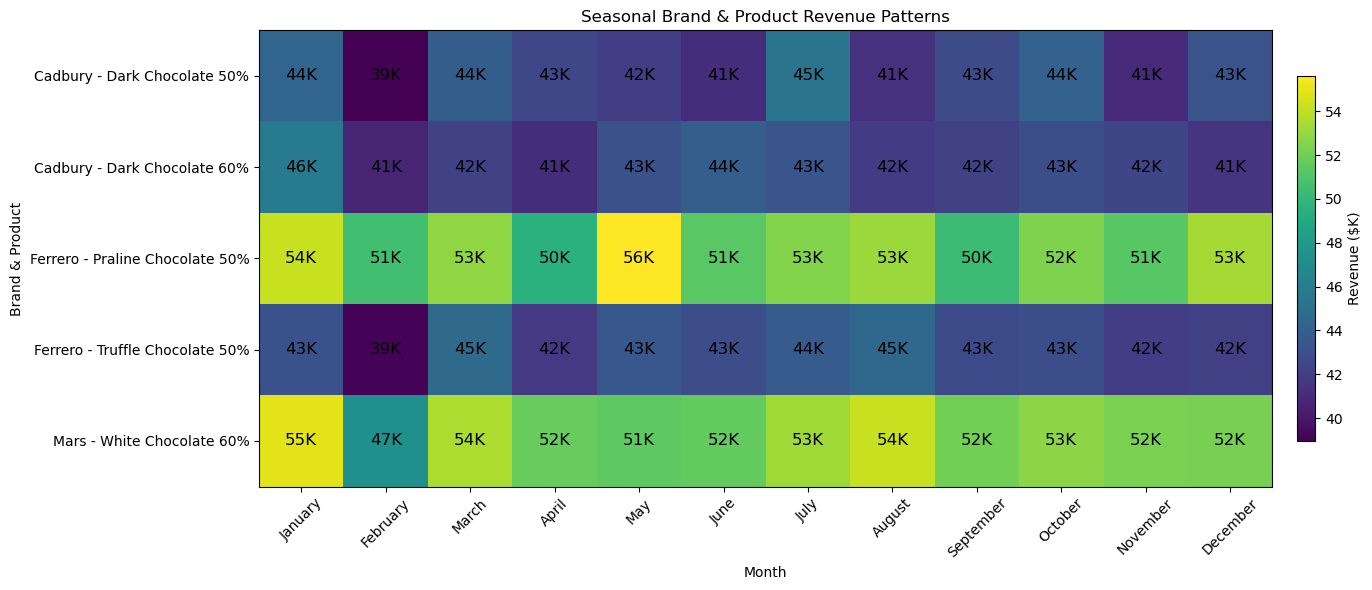

In [221]:
# Create combined brand + product label
merged["product_label"] = (
    merged["brand"] + " - " + merged["product_name"]
)

# Convert date
merged["order_date"] = pd.to_datetime(merged["order_date"])

# Extract month name
merged["month"] = merged["order_date"].dt.month_name()

# Month order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Monthly revenue by product
monthly_sales = merged.groupby(
    ["product_label", "month"]
)["revenue"].sum().reset_index()

# Top 5 products
top_products = (
    merged.groupby("product_label")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Filter top products
monthly_sales = monthly_sales[
    monthly_sales["product_label"].isin(top_products)
]

# Set month order
monthly_sales["month"] = pd.Categorical(
    monthly_sales["month"],
    categories=month_order,
    ordered=True
)

# Pivot table
heatmap_data = monthly_sales.pivot(
    index="product_label",
    columns="month",
    values="revenue"
).fillna(0)

# Convert to K
heatmap_data_k = heatmap_data / 1000

# Create heatmap
plt.figure(figsize=(15, 6))

plt.imshow(
    heatmap_data_k,
    aspect="auto"
)

# Axis labels
plt.xticks(
    range(len(heatmap_data_k.columns)),
    heatmap_data_k.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_data_k.index)),
    heatmap_data_k.index
)

# Add values
for i in range(len(heatmap_data_k.index)):
    for j in range(len(heatmap_data_k.columns)):
        plt.text(
            j,
            i,
            f'{heatmap_data_k.iloc[i, j]:.0f}K',
            ha='center',
            va='center',
            fontsize=12
        )

# Colorbar
cbar = plt.colorbar(
    shrink=0.8,
    pad=0.02
)

cbar.set_label("Revenue ($K)")

# Titles
plt.title("Seasonal Brand & Product Revenue Patterns")
plt.xlabel("Month")
plt.ylabel("Brand & Product")

plt.tight_layout()

plt.show()

## Seasonal Brand & Product Revenue Pattern Analysis

### Key Business Insights

- **Mars - White Chocolate 60% consistently generated the highest monthly revenue performance,** maintaining strong revenue levels between **47K–55K** throughout the year. This indicates highly stable customer demand and strong year-round product performance.

- **Ferrero - Praline Chocolate 50% also demonstrated strong and stable monthly revenue trends,** consistently remaining within the **50K–56K** range, making it another reliable revenue-driving product category.

- **Cadbury - Dark Chocolate 50% and Cadbury - Dark Chocolate 60% maintained moderate but stable monthly sales performance,** suggesting dependable customer demand with relatively low seasonality risk.

- **Ferrero - Truffle Chocolate 50% showed the lowest overall monthly revenue among the analyzed products,** though its sales remained relatively stable throughout the year.

- Several products experienced comparatively weaker sales during:
  - **February**
  - **April**
  - **November**

  suggesting potential seasonal slowdowns or reduced customer purchasing activity during these periods.

- Stronger revenue performance was observed during:
  - **January**
  - **March**
  - **May**
  - **July**
  - **August**
  - **December**

  indicating periods of stronger customer demand and potential promotional effectiveness.

---

## Strategic Business Impact

The analysis suggests that the company benefits from a relatively stable premium chocolate portfolio with limited extreme seasonality risk.

Products such as:
- **Mars - White Chocolate 60%**
- **Ferrero - Praline Chocolate 50%**

can serve as:
- core inventory products
- stable revenue drivers
- long-term forecasting anchors
- high-priority inventory allocation candidates

The relatively stable monthly revenue distribution across most products indicates:
- predictable customer purchasing behavior
- operational stability
- improved forecasting reliability
- lower inventory volatility risk

---

## Business Recommendations

To optimize revenue performance and operational efficiency, the company should consider:

- **prioritizing inventory allocation for consistently high-performing products**
- **leveraging strong-performing months for promotional expansion**
- **improving targeted marketing during weaker seasonal periods**
- **using stable products for long-term inventory forecasting**
- **expanding premium product positioning strategies**
- **developing cross-selling initiatives around top-performing brands**

The findings indicate that the business currently maintains:
- strong year-round customer demand
- stable premium product performance
- balanced seasonal revenue behavior
- limited dependence on short-term seasonal sales spikes

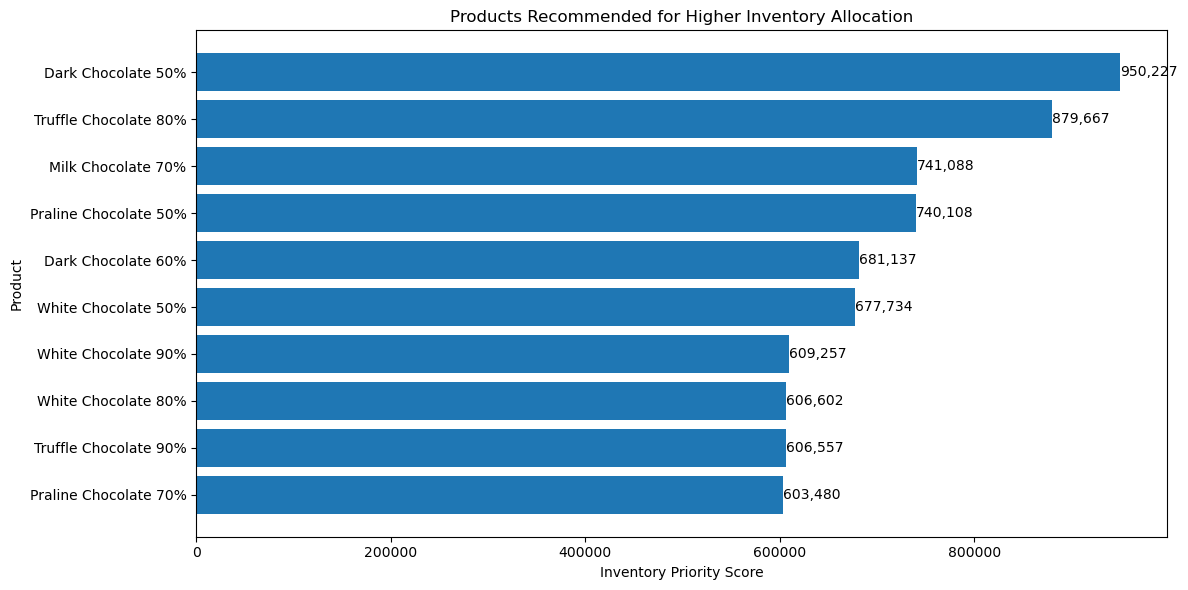

In [223]:
# Product inventory allocation analysis
inventory_analysis = merged.groupby("product_name").agg({
    "revenue": "sum",
    "quantity": "sum",
    "profit": "sum"
})
# Profit margin %
inventory_analysis["profit_margin"] = (
    inventory_analysis["profit"] / inventory_analysis["revenue"]
) * 100

# Inventory priority score
inventory_analysis["inventory_score"] = (
    inventory_analysis["revenue"] * 0.5 +
    inventory_analysis["quantity"] * 0.3 +
    inventory_analysis["profit_margin"] * 0.2
)

# Top inventory allocation candidates
top_inventory = inventory_analysis.sort_values(
    by="inventory_score",
    ascending=False
).head(10)

# Create chart
plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_inventory.index,
    top_inventory["inventory_score"]
)

# Labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center'
    )

# Titles
plt.title("Products Recommended for Higher Inventory Allocation")
plt.xlabel("Inventory Priority Score")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

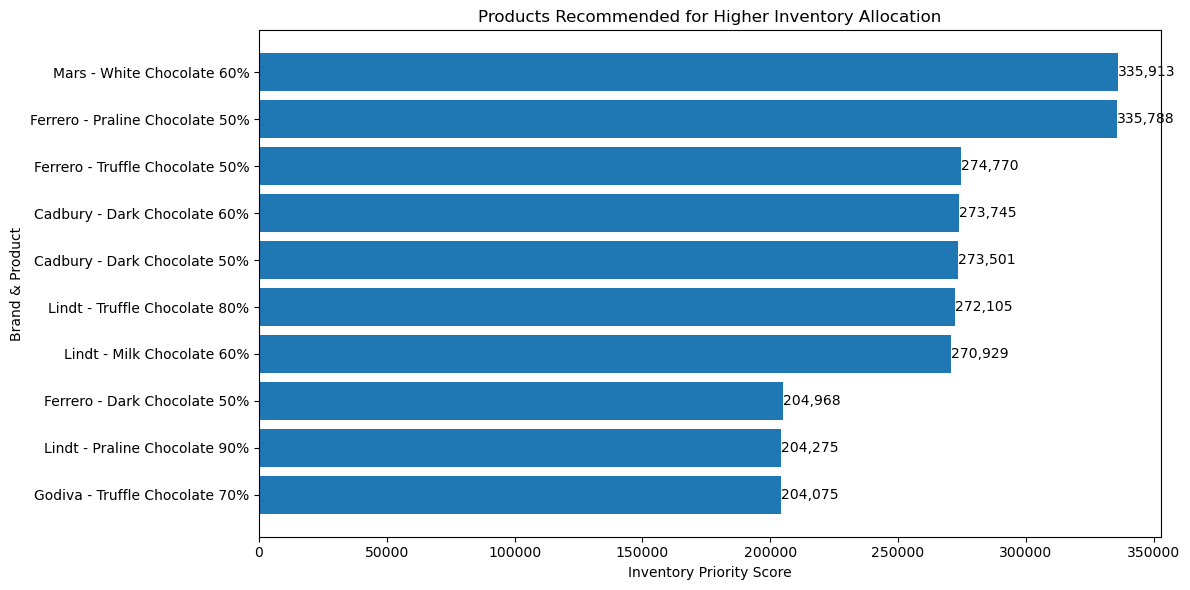

In [219]:
# Create combined brand + product label
merged["product_label"] = (
    merged["brand"] + " - " + merged["product_name"]
)

# Product inventory allocation analysis
inventory_analysis = merged.groupby("product_label").agg({
    "revenue": "sum",
    "quantity": "sum",
    "profit": "sum"
})

# Profit margin %
inventory_analysis["profit_margin"] = (
    inventory_analysis["profit"] / inventory_analysis["revenue"]
) * 100

# Inventory priority score
inventory_analysis["inventory_score"] = (
    inventory_analysis["revenue"] * 0.5 +
    inventory_analysis["quantity"] * 0.3 +
    inventory_analysis["profit_margin"] * 0.2
)

# Top inventory allocation candidates
top_inventory = inventory_analysis.sort_values(
    by="inventory_score",
    ascending=False
).head(10)

# Create chart
plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_inventory.index,
    top_inventory["inventory_score"]
)

# Labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center'
    )

# Titles
plt.title("Products Recommended for Higher Inventory Allocation")
plt.xlabel("Inventory Priority Score")
plt.ylabel("Brand & Product")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Inventory Allocation Priority Analysis

### Key Business Insights

- **Mars - White Chocolate 60% achieved the highest Inventory Priority Score (335.9K),** making it the strongest candidate for increased inventory allocation based on its combined revenue performance, sales demand, and profitability contribution.

- **Ferrero - Praline Chocolate 50% closely followed as one of the highest-priority inventory products,** demonstrating strong overall business value and stable customer demand across multiple performance factors.

- Products within the **Ferrero, Mars, Lindt, and Cadbury premium chocolate segments** consistently ranked among the highest inventory allocation priorities, indicating stronger customer preference for premium and specialty chocolate categories.

- **Ferrero - Truffle Chocolate 50%, Cadbury - Dark Chocolate 60%, and Lindt - Truffle Chocolate 80%** also demonstrated strong inventory allocation potential due to balanced performance across:
  - revenue generation
  - demand volume
  - profitability contribution

- The relatively small performance gap among several top-ranked products suggests that the company maintains a diversified portfolio of strong-performing inventory candidates rather than relying heavily on a single dominant product.

- Products with lower Inventory Priority Scores may:
  - contribute less business value
  - generate weaker demand
  - create higher inventory carrying risk
  - require inventory optimization or demand stimulation strategies

---

## Strategic Business Impact

The analysis highlights which products should receive:
- higher replenishment priority
- stronger inventory support
- optimized stock allocation
- enhanced supply chain focus

High-priority products are more likely to:
- drive stable revenue growth
- improve inventory turnover
- reduce stockout risk
- strengthen customer satisfaction
- support long-term profitability performance

The findings also indicate that premium chocolate products currently represent the company’s strongest operational and financial inventory drivers.

---

## Business Recommendations

To improve inventory efficiency and operational performance, the company should consider:

- **prioritizing inventory allocation toward top-scoring premium products**
- **increasing replenishment frequency for high-demand products**
- **reducing inventory exposure for weaker-performing products**
- **aligning supply chain planning with demand-driven inventory priorities**
- **leveraging high-performing products for promotional and cross-selling strategies**
- **continuously monitoring profitability and sales trends for inventory optimization**

The analysis suggests that the company’s strongest inventory opportunities currently exist within:
- premium chocolate categories
- stable high-demand products
- high-margin product segments